In [37]:
# Install des packages 
install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", "caret", "randomForest", "lmtest", "car", "ggrepel", "scales", "viridis", "outliers", "glmnet", "dplyr", "rlang"))

Installation des packages dans ‘/home/ymokhtar/R/x86_64-pc-linux-gnu-library/4.3’
(car ‘lib’ n'est pas spécifié)

Warning message in install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", :
“l'installation du package ‘corrplot’ a eu un statut de sortie non nul”
Warning message in install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", :
“l'installation du package ‘caret’ a eu un statut de sortie non nul”
Warning message in install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", :
“l'installation du package ‘randomForest’ a eu un statut de sortie non nul”
Warning message in install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", :
“l'installation du package ‘lmtest’ a eu un statut de sortie non nul”
Warning message in install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", :
“l'installation du package ‘glmnet’ a eu un statut de sortie non nul”
Warning message in install.packages(c("tidyverse", "FactoMineR",

In [1]:
install.packages("ggplot2")

Installation du package dans ‘/home/ymokhtar/R/x86_64-pc-linux-gnu-library/4.3’
(car ‘lib’ n'est pas spécifié)



In [3]:

library(tidyverse)
library(FactoMineR)
library(factoextra)
library(corrplot)
library(caret)
library(randomForest)
library(lmtest)
library(car)
library(ggrepel)
library(scales)
library(viridis)
library(outliers)
library(glmnet)
library(dplyr)
library(corrplot)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/

corrplot 0.95 loaded

Le chargement a nécessité le package : lattice


Attachement du package : ‘caret’


L'objet suivant est masqué depuis ‘package:purrr’:

    lift


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attachement du package : ‘randomForest’


L'objet suivant e

# Quels sont les facteurs associés au succès commercial d'un jeu ?

## Définir le succès commercial

In [4]:
df <- read_csv("clean.csv")

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 113121 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): Name, Release date, Estimated owners, Supported languages, Full au...
dbl (23): AppID, Peak CCU, Required age, Price, Discount, DLC count, Reviews...
lgl  (4): Windows, Mac, Linux, Score rank

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### Transformations des features du dataset pour préparer notre variable success_score

In [5]:
df_clean <- df %>%

  select(-`Score rank`, -`User score`) %>%
  
  
  mutate(
    total_reviews = ifelse(`Ratio positive vote` > 0 & !is.na(`Ratio positive vote`),
                           round(Positive / `Ratio positive vote`),
                           Positive),  # si ratio NA, on a 0 négatifs
    Negative = total_reviews - Positive
  ) %>%
  
  # mediane des owners pour tout le monde
  mutate(
    owners_low  = as.numeric(str_extract(`Estimated owners`, "^[0-9]+")),
    owners_high = as.numeric(str_extract(`Estimated owners`, "[0-9]+$")),
    owners_midpoint = (owners_low + owners_high) / 2
  ) %>%
  
  
  mutate(
    nb_languages = str_count(`Supported languages`, ",") + 1
  ) %>%
  
  
  mutate(
    log_owners          = log1p(owners_midpoint),
    log_recommendations = log1p(Recommendations),
    log_peak_ccu        = log1p(`Peak CCU`),
    log_median_playtime = log1p(`Median playtime forever`)
  )

### Évaluation de la fiabilité des ratings avec le Wilson Score

In [6]:
wilson_score <- function(positive, negative, z = 1.96) {
  n <- positive + negative
  if (n == 0) return(NA)
  p_hat <- positive / n
  numerator   <- p_hat + z^2/(2*n) - z * sqrt(p_hat*(1-p_hat)/n + z^2/(4*n^2))
  denominator <- 1 + z^2/n
  return(numerator / denominator)
}

df_clean <- df_clean %>%
  mutate(
    wilson = mapply(wilson_score, Positive, Negative)
  )

### Création de la variable sucess_score

In [7]:
df_clean <- df_clean %>%
  mutate(
    success_score = 0.5 * log_owners +
                    0.3 * log_recommendations +
                    0.2 * wilson
  )

Visualisation de la distribution du score de succès commercial selon les jeux

Warning message:
“Removed 33644 rows containing non-finite outside the scale range
(`stat_bin()`).”


[1] 1493

Name,success_score,log_owners,log_recommendations,wilson
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Counter-Strike 2,14.20355,18.82615,15.39045,0.8667080
PUBG: BATTLEGROUNDS,13.84493,18.82615,14.37699,0.5938040
Grand Theft Auto V Legacy,13.57113,18.13300,14.43300,0.8736560
Black Myth: Wukong,13.36022,18.13300,13.66820,0.9663009
Left 4 Dead 2,13.32811,18.13300,13.55535,0.9750388
Palworld,13.07861,18.13300,12.74684,0.9402968
Terraria,13.07030,17.37086,13.96652,0.9745576
Tom Clancy's Rainbow Six® Siege X,13.05828,17.37086,14.01752,0.8379904
Call of Duty®,13.05575,18.13300,12.90656,0.5864306


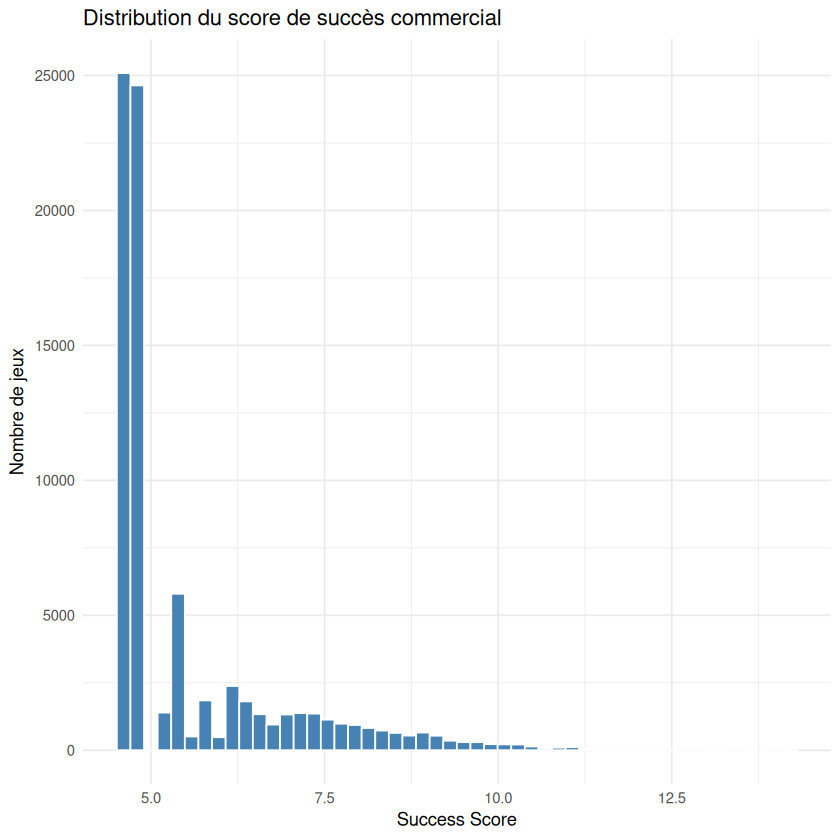

In [8]:
ggplot(df_clean, aes(x = success_score)) +
  geom_histogram(bins = 50, fill = "steelblue", color = "white") +
  labs(title = "Distribution du score de succès commercial",
       x = "Success Score", y = "Nombre de jeux") +
  theme_minimal()

# idd les outliers 
df_clean <- df_clean %>%
  mutate(
    success_zscore = scale(success_score)[,1],
    is_outlier = abs(success_zscore) > 3
  )

# combien d'outliers 
sum(df_clean$is_outlier, na.rm = TRUE)

df_clean %>%
  filter(is_outlier) %>%
  select(Name, success_score, log_owners, log_recommendations, wilson) %>%
  arrange(desc(success_score)) %>%
  head(20)


Score pour Jusant par exemple (bon score qui reflète un bon succès en réalité bien que le jeu soit indie et possède bien moins de joueurs qu'un AAA) le score le prend en compte. 

In [9]:
df_clean %>%
  filter(str_detect(Name, "Jusant")) %>%
  select(Name, success_score, log_owners, log_recommendations, 
         wilson, owners_midpoint, Positive, Negative)

Name,success_score,log_owners,log_recommendations,wilson,owners_midpoint,Positive,Negative
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Jusant,9.02752,12.76569,8.200014,0.9233531,350000,4649,346


# Quels facteurs sont associés au succès commercial
### Visualisation des corrélations entre variables avec un corrplot afin pour avoir une première idée des relations avec le succès commercial.

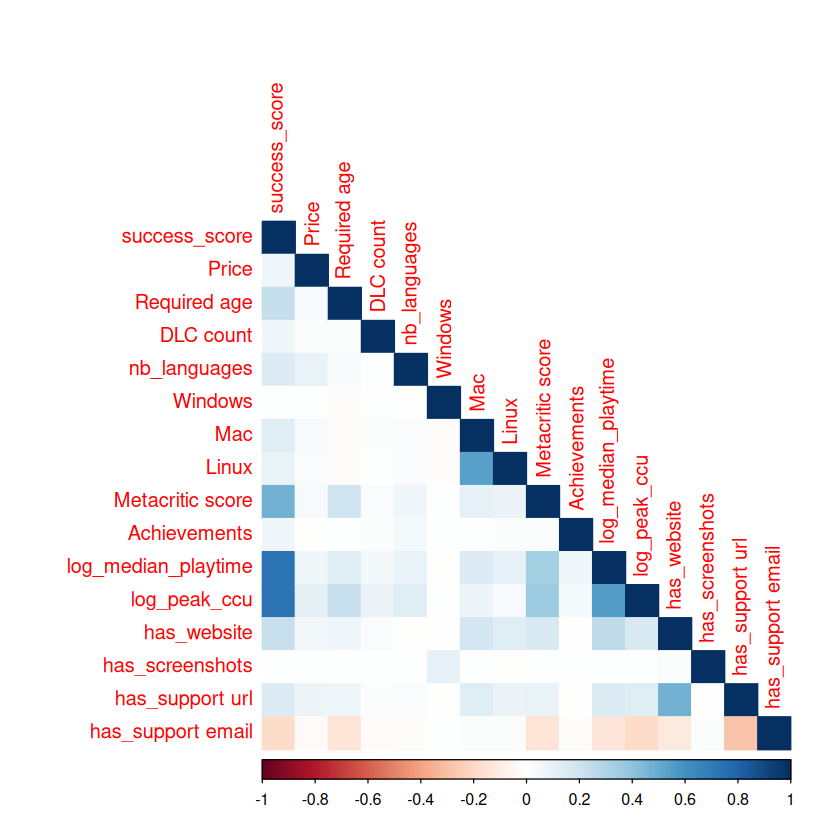

In [12]:
cor_matrix <- cor(data_model)
corrplot(cor_matrix, method = "color", type = "lower")

### Modèle LASSO plus robuste pour déterminer ces facteurs

                       lambda.min
log_peak_ccu         0.4662388923
log_median_playtime  0.2379539404
Windows              0.1184826362
has_screenshots      0.0854318195
has_support email   -0.0829453654
Linux                0.0465230974
Mac                  0.0356853542
Required age         0.0310955143
has_website          0.0275452355
Metacritic score     0.0135244098
has_support url     -0.0133258459
nb_languages         0.0041624088
Price               -0.0025456212
Achievements         0.0001334702
DLC count            0.0000000000


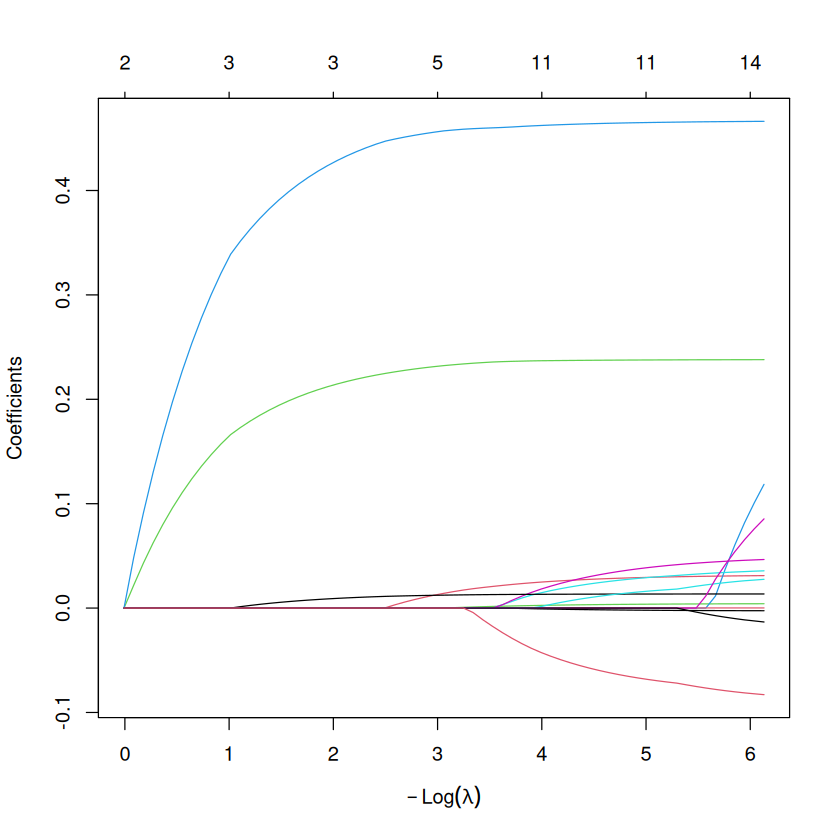

In [11]:
data_model <- df_clean %>%
  select(
    success_score,
    Price, `Required age`, `DLC count`,
    nb_languages, Windows, Mac, Linux,
    `Metacritic score`, Achievements,
    log_median_playtime, log_peak_ccu,
    has_website, has_screenshots,
    `has_support url`, `has_support email`
  ) %>%
  mutate(across(where(is.logical), as.numeric)) %>%
  drop_na()

X <- data.matrix(data_model %>% select(-success_score))
y <- data_model$success_score
set.seed(42)

lasso_cv <- cv.glmnet(
  X, y,
  alpha = 1,        # LASSO
  standardize = TRUE
)

set.seed(42)

lasso_cv <- cv.glmnet(
  X, y,
  alpha = 1,
  standardize = TRUE
)

plot(lasso_cv$glmnet.fit, xvar = "lambda")

coef_lasso <- coef(lasso_cv, s = "lambda.min")




important_vars <- coef_lasso[-1, , drop = FALSE]  # enlever l'intercept
important_vars <- as.matrix(important_vars)
important_vars <- important_vars[order(abs(important_vars[,1]), decreasing = TRUE), , drop = FALSE]


print(important_vars)

## Analyse de ces facteurs 

### DLC Count (facteur décidés par les devs, pas capturé par le LASSO)
Motivation d'étudier le DLC Count : 
DLC count à 0 dans LASSO  :  redondance avec log_peak_ccu (c'est pas une question de causalité)

DLC count comme indicateur : causalité ou conséquences de succès préalable ? (que le LASSO ne peut pas voir)


	Wilcoxon rank sum test with continuity correction

data:  log_owners by has_dlc
W = 607334130, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  wilson by has_dlc
W = 257778151, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  log_recommendations by has_dlc
W = 541872292, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


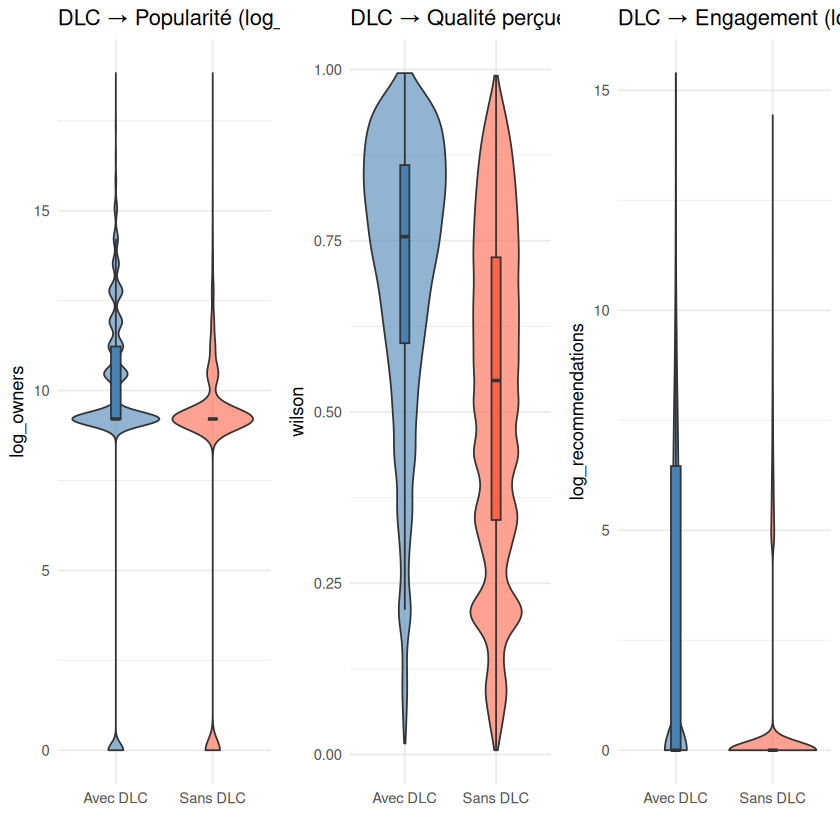

In [13]:
df_analysis <- df_clean %>%
  mutate(
    has_dlc = `DLC count` > 0,
    price_group = case_when(
      Price == 0 ~ "Gratuit",
      Price < 5  ~ "< 5e",
      Price < 15 ~ "5-15e",
      Price < 30 ~ "15-30e",
      TRUE       ~ "+30e"
    ) %>% factor(levels = c("Gratuit", "< 5e", "5-15e", "15-30e", "+30e"))
  )

plot_binary_vs_success <- function(data, binary_var, success_var, 
                                    label_true, label_false, title) {
  data %>%
    filter(!is.na(.data[[success_var]]), !is.na(.data[[binary_var]])) %>%
    mutate(group = ifelse(.data[[binary_var]], label_true, label_false)) %>%
    ggplot(aes(x = group, y = .data[[success_var]], fill = group)) +
    geom_violin(alpha = 0.6) +
    geom_boxplot(width = 0.1, outlier.shape = NA) +
    scale_fill_manual(values = c("steelblue", "tomato")) +
    labs(title = title, x = "", y = success_var) +
    theme_minimal() +
    theme(legend.position = "none") 
}

p1a <- plot_binary_vs_success(df_analysis, "has_dlc", "log_owners",
                               "Avec DLC", "Sans DLC",
                               "DLC → Popularité (log_owners)")
p1b <- plot_binary_vs_success(df_analysis, "has_dlc", "wilson",
                               "Avec DLC", "Sans DLC",
                               "DLC → Qualité perçue (wilson)")
p1c <- plot_binary_vs_success(df_analysis, "has_dlc", "log_recommendations",
                               "Avec DLC", "Sans DLC",
                               "DLC → Engagement (log_recommendations)")

gridExtra::grid.arrange(p1a, p1b, p1c, ncol = 3)

# Tests statistiques
wilcox.test(log_owners ~ has_dlc, data = df_analysis)
wilcox.test(wilson ~ has_dlc, data = df_analysis)
wilcox.test(log_recommendations ~ has_dlc, data = df_analysis)

La présence de DLC est significativement associée aux trois composantes du succès (p < 2.2e-16). L'effet le plus marqué concerne la qualité perçue, les jeux avec DLC affichent un Wilson Score plus élevé et moins dispersé, laisse penser qu'ils proviennent de studios plus établis produisant des jeux mieux reçus. Cet effet est probablement indirect : Les jeux a succès font des DLC pour profiter encore plus de ce succès plutôt que les jeux font succès car ils possèdent un DLC, c'est un lien de causalité inversé.

Warning message:
“Removed 33644 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 33644 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


dlc_group,wilson_median,owners_median,recomm_median,n
<fct>,<dbl>,<dbl>,<dbl>,<int>
0 DLC,0.5458917,9.21044,0.000000,95519
1-5 DLC,0.7529600,9.21044,0.000000,16145
6-10 DLC,0.7751476,11.22526,6.346402,786
11-100 DLC,0.7885430,11.91840,7.105376,638
100+ DLC,0.8192883,13.52783,7.944137,33



	Kruskal-Wallis rank sum test

data:  wilson by dlc_group
Kruskal-Wallis chi-squared = 6499.3, df = 4, p-value < 2.2e-16



	Kruskal-Wallis rank sum test

data:  log_owners by dlc_group
Kruskal-Wallis chi-squared = 5330.7, df = 4, p-value < 2.2e-16


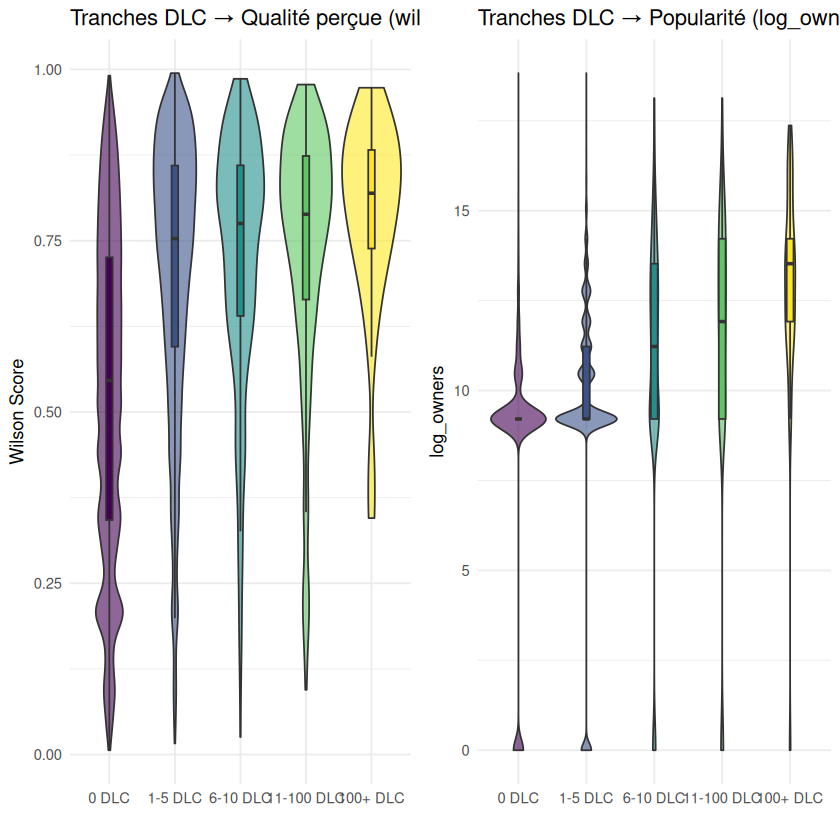

In [14]:
df_analysis <- df_analysis %>%
  mutate(dlc_group = case_when(
    `DLC count` == 0        ~ "0 DLC",
    `DLC count` <= 5        ~ "1-5 DLC",
    `DLC count` <= 10       ~ "6-10 DLC",
    `DLC count` <= 100      ~ "11-100 DLC",
    TRUE                    ~ "100+ DLC"
  ) %>% factor(levels = c("0 DLC", "1-5 DLC", "6-10 DLC", "11-100 DLC", "100+ DLC")))

# Wilson par tranche DLC
p_dlc_wilson <- ggplot(df_analysis, aes(x = dlc_group, y = wilson, fill = dlc_group)) +
  geom_violin(alpha = 0.6) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Tranches DLC → Qualité perçue (wilson)", x = "", y = "Wilson Score") +
  theme_minimal() +
  theme(legend.position = "none")

# log_owners par tranche DLC
p_dlc_owners <- ggplot(df_analysis, aes(x = dlc_group, y = log_owners, fill = dlc_group)) +
  geom_violin(alpha = 0.6) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Tranches DLC → Popularité (log_owners)", x = "", y = "log_owners") +
  theme_minimal() +
  theme(legend.position = "none")

gridExtra::grid.arrange(p_dlc_wilson, p_dlc_owners, ncol = 2)

# Stats par groupe
df_analysis %>%
  group_by(dlc_group) %>%
  summarise(
    wilson_median    = median(wilson, na.rm = TRUE),
    owners_median    = median(log_owners, na.rm = TRUE),
    recomm_median    = median(log_recommendations, na.rm = TRUE),
    n = n()
  )

kruskal.test(wilson ~ dlc_group, data = df_analysis)
kruskal.test(log_owners ~ dlc_group, data = df_analysis)

Avoir ou ne pas avoir de DLC ne change pas la popularité, c'est seulement à partir de +6 DLC que le saut apparaît. Ce qui confirme bien notre causalité inversée.

## Prix



	Kruskal-Wallis rank sum test

data:  log_owners by price_group
Kruskal-Wallis chi-squared = 6138.7, df = 4, p-value < 2.2e-16



	Kruskal-Wallis rank sum test

data:  wilson by price_group
Kruskal-Wallis chi-squared = 1399.4, df = 4, p-value < 2.2e-16



	Kruskal-Wallis rank sum test

data:  log_recommendations by price_group
Kruskal-Wallis chi-squared = 6119.6, df = 4, p-value < 2.2e-16


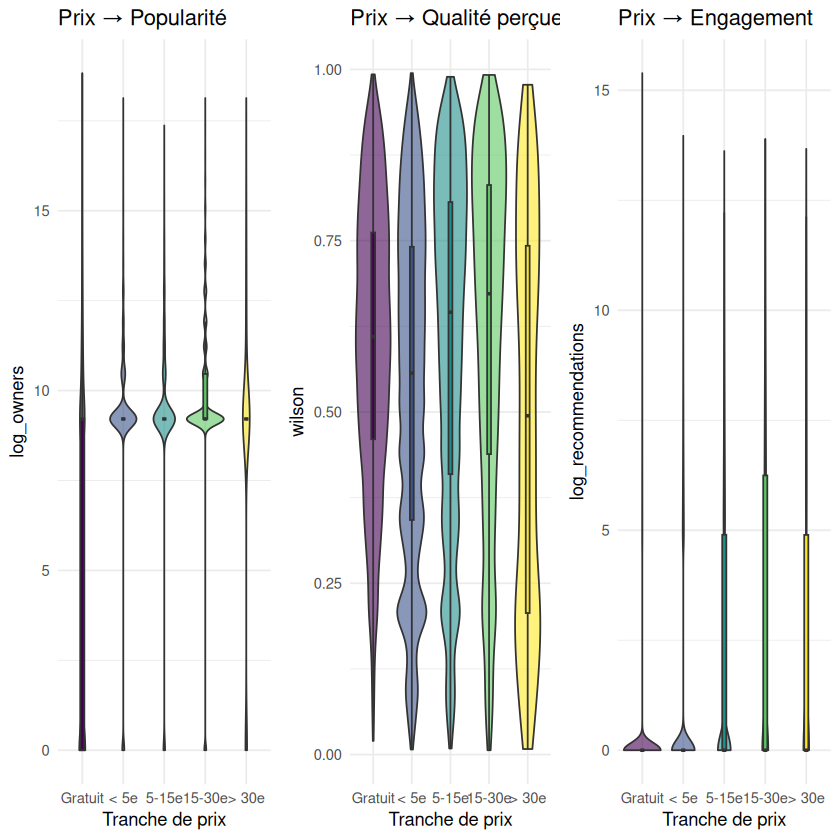

In [14]:
# Visualisation par groupe de prix
plot_price <- function(success_var, title) {
  df_analysis %>%
    filter(!is.na(.data[[success_var]])) %>%
    ggplot(aes(x = price_group, y = .data[[success_var]], fill = price_group)) +
    geom_violin(alpha = 0.6) +
    geom_boxplot(width = 0.1, outlier.shape = NA) +
    scale_fill_viridis_d() +
    labs(title = title, x = "Tranche de prix", y = success_var) +
    theme_minimal() +
    theme(legend.position = "none")
}

p2a <- plot_price("log_owners", "Prix → Popularité")
p2b <- plot_price("wilson", "Prix → Qualité perçue")
p2c <- plot_price("log_recommendations", "Prix → Engagement")

gridExtra::grid.arrange(p2a, p2b, p2c, ncol = 3)

# Test Kruskal-Wallis (variable catégorielle)
kruskal.test(log_owners ~ price_group, data = df_analysis)
kruskal.test(wilson ~ price_group, data = df_analysis)
kruskal.test(log_recommendations ~ price_group, data = df_analysis)

Le prix est significativement associé à la qualité perçue (wilson) mais peu à la popularité brute (log_owners). Les jeux premium (+ de 30e) affichent un Wilson Score systématiquement plus élevé, qui laisse penser à un effet de sélection : les joueurs qui investissent davantage sont plus exigeants dans leurs choix et donc plus satisfaits. À l'inverse, la gratuité maximise l'accessibilité sans garantir la satisfaction. Le LASSO attribue un coefficient négatif au prix, cohérent avec l'effet : un jeu gratuit touche plus de joueurs même si sa qualité perçue est moins bonne.

On peut aussi s'intéresser à la relation inverse :

wilson_group,prix_median,prix_moyen,n
<fct>,<dbl>,<dbl>,<int>
< 0.60,2.99,5.410252,37246
0.60-0.75,3.49,5.357206,14802
0.75-0.90,3.99,5.915675,14747
> 0.90,4.99,7.067612,4417


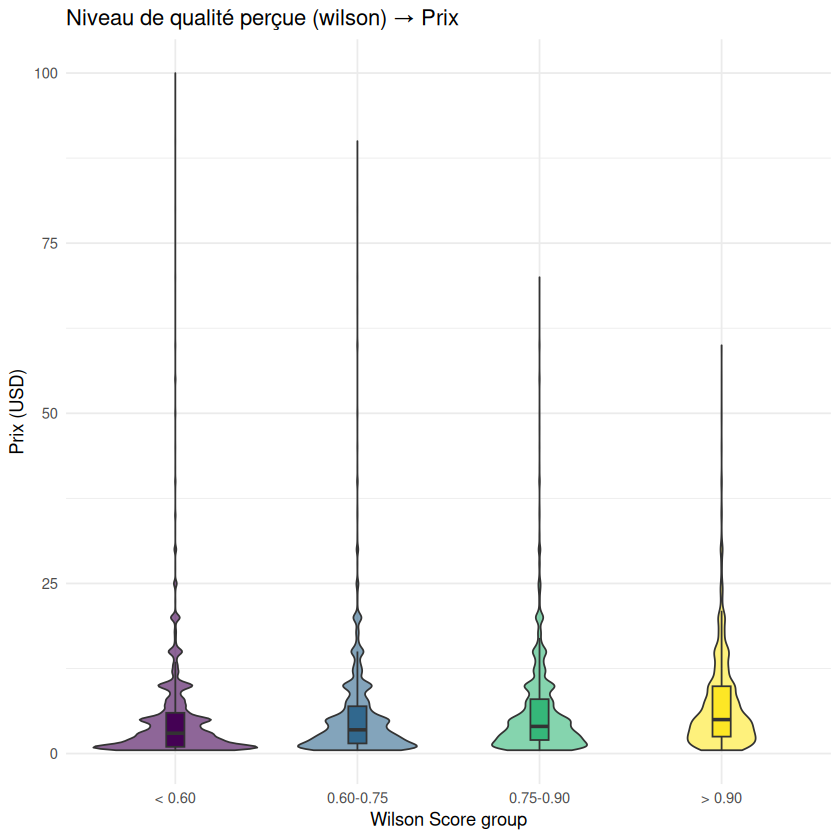

In [16]:
df_analysis %>%
  filter(!is.na(wilson), Price > 0) %>%
  mutate(wilson_group = case_when(
    wilson < 0.6  ~ "< 0.60",
    wilson < 0.75 ~ "0.60-0.75",
    wilson < 0.90 ~ "0.75-0.90",
    TRUE          ~ "> 0.90"
  ) %>% factor(levels = c("< 0.60", "0.60-0.75", "0.75-0.90", "> 0.90"))) %>%
  group_by(wilson_group) %>%
  summarise(
    prix_median = median(Price, na.rm = TRUE),
    prix_moyen  = mean(Price, na.rm = TRUE),
    n = n()
  )

# Visualisation
df_analysis %>%
  filter(!is.na(wilson), Price > 0, Price < 100) %>%
  mutate(wilson_group = case_when(
    wilson < 0.6  ~ "< 0.60",
    wilson < 0.75 ~ "0.60-0.75",
    wilson < 0.90 ~ "0.75-0.90",
    TRUE          ~ "> 0.90"
  ) %>% factor(levels = c("< 0.60", "0.60-0.75", "0.75-0.90", "> 0.90"))) %>%
  ggplot(aes(x = wilson_group, y = Price, fill = wilson_group)) +
  geom_violin(alpha = 0.6) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Niveau de qualité perçue (wilson) → Prix",
       x = "Wilson Score group", y = "Prix (USD)") +
  theme_minimal() +
  theme(legend.position = "none")

Les jeux mieux perçus sont légèrement plus chers (médiane 4.99e vs 2.99e) pour les moins bien notés, mais l'effet reste modeste, la qualité perçue n'est pas un déterminant fort du prix sur Steam, la majorité des jeux sont très peu chers indépendamment de leur qualité.

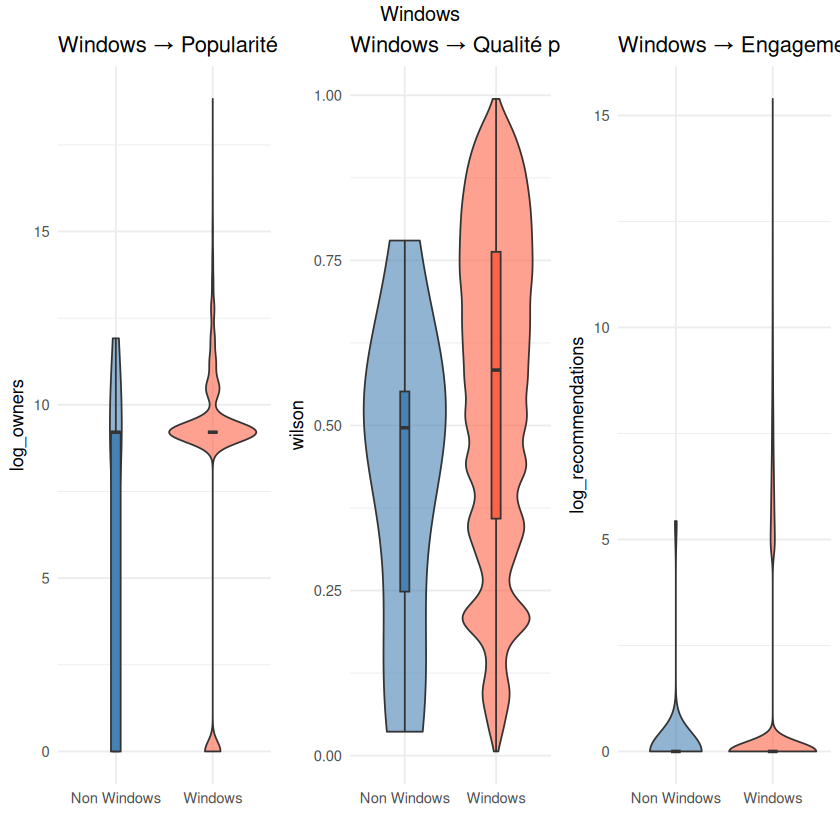

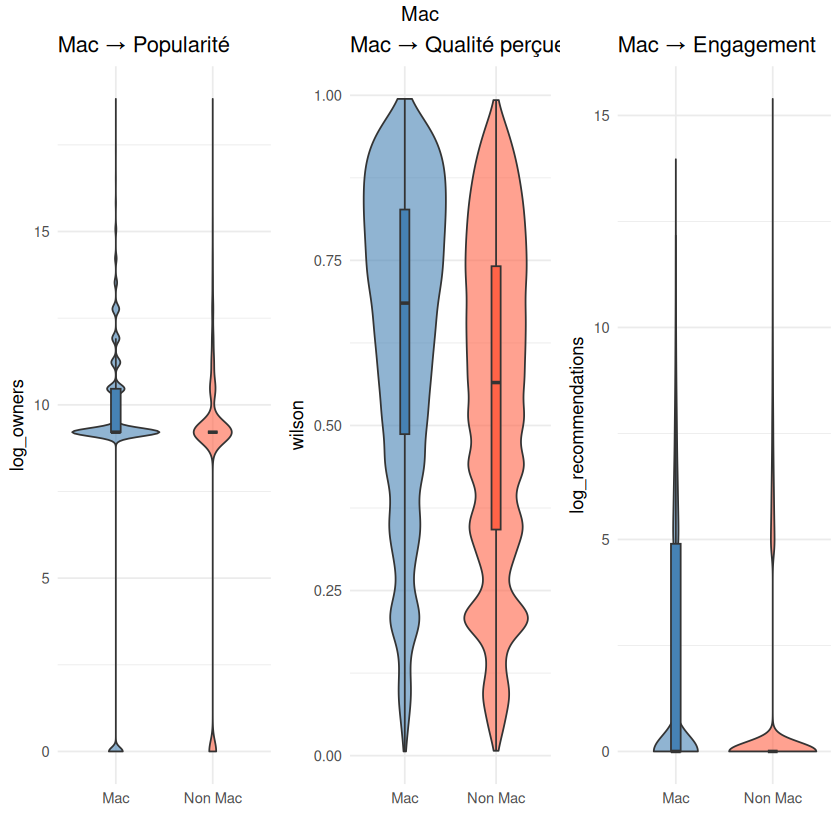

=== WINDOWS ===



	Wilcoxon rank sum test with continuity correction

data:  log_owners by Windows
W = 1216525, p-value = 0.001464
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  wilson by Windows
W = 269924, p-value = 0.07903
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  log_recommendations by Windows
W = 1439468, p-value = 0.033
alternative hypothesis: true location shift is not equal to 0


=== MAC ===


...

=== LINUX ===



	Wilcoxon rank sum test with continuity correction

data:  log_owners by Linux
W = 691744576, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  wilson by Linux
W = 303310150, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  log_recommendations by Linux
W = 695715978, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


Windows_owners_med,Windows_wilson_med,Windows_recomm_med,Mac_owners_med,Mac_wilson_med,Mac_recomm_med,Linux_owners_med,Linux_wilson_med,Linux_recomm_med
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
9.21044,0.5838848,0,9.21044,0.6853073,0,9.21044,0.6804971,0


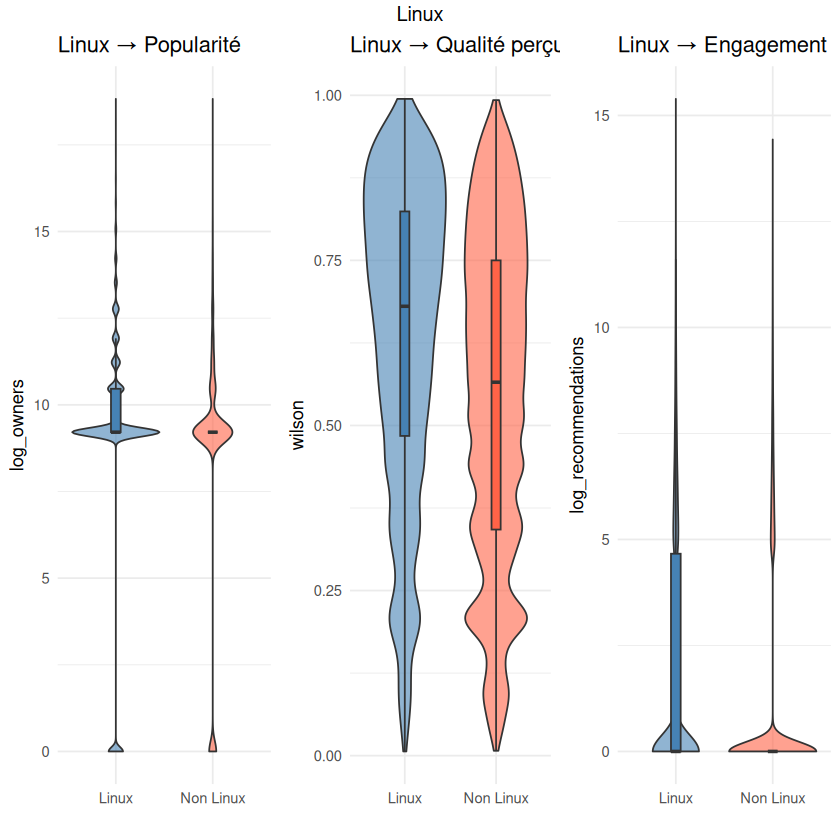

In [17]:
# Support OS vs composantes du succès
p_win_owners <- plot_binary_vs_success(df_analysis, "Windows", "log_owners",
                               "Windows", "Non Windows", "Windows → Popularité")
p_win_wilson <- plot_binary_vs_success(df_analysis, "Windows", "wilson",
                               "Windows", "Non Windows", "Windows → Qualité perçue")
p_win_recomm <- plot_binary_vs_success(df_analysis, "Windows", "log_recommendations",
                               "Windows", "Non Windows", "Windows → Engagement")

p_mac_owners <- plot_binary_vs_success(df_analysis, "Mac", "log_owners",
                               "Mac", "Non Mac", "Mac → Popularité")
p_mac_wilson <- plot_binary_vs_success(df_analysis, "Mac", "wilson",
                               "Mac", "Non Mac", "Mac → Qualité perçue")
p_mac_recomm <- plot_binary_vs_success(df_analysis, "Mac", "log_recommendations",
                               "Mac", "Non Mac", "Mac → Engagement")

p_lin_owners <- plot_binary_vs_success(df_analysis, "Linux", "log_owners",
                               "Linux", "Non Linux", "Linux → Popularité")
p_lin_wilson <- plot_binary_vs_success(df_analysis, "Linux", "wilson",
                               "Linux", "Non Linux", "Linux → Qualité perçue")
p_lin_recomm <- plot_binary_vs_success(df_analysis, "Linux", "log_recommendations",
                               "Linux", "Non Linux", "Linux → Engagement")

# Grid par OS
gridExtra::grid.arrange(p_win_owners, p_win_wilson, p_win_recomm, ncol = 3,
                        top = "Windows")
gridExtra::grid.arrange(p_mac_owners, p_mac_wilson, p_mac_recomm, ncol = 3,
                        top = "Mac")
gridExtra::grid.arrange(p_lin_owners, p_lin_wilson, p_lin_recomm, ncol = 3,
                        top = "Linux")

# Tests statistiques
cat("=== WINDOWS ===\n")
wilcox.test(log_owners ~ Windows, data = df_analysis)
wilcox.test(wilson ~ Windows, data = df_analysis)
wilcox.test(log_recommendations ~ Windows, data = df_analysis)

cat("=== MAC ===\n")
wilcox.test(log_owners ~ Mac, data = df_analysis)
wilcox.test(wilson ~ Mac, data = df_analysis)
wilcox.test(log_recommendations ~ Mac, data = df_analysis)

cat("=== LINUX ===\n")
wilcox.test(log_owners ~ Linux, data = df_analysis)
wilcox.test(wilson ~ Linux, data = df_analysis)
wilcox.test(log_recommendations ~ Linux, data = df_analysis)

# Stats descriptives
df_analysis %>%
  summarise(
    across(c(Windows, Mac, Linux), 
           list(
             owners_med  = ~median(log_owners[. == TRUE], na.rm = TRUE),
             wilson_med  = ~median(wilson[. == TRUE], na.rm = TRUE),
             recomm_med  = ~median(log_recommendations[. == TRUE], na.rm = TRUE)
           ))
  )

Le support Mac et Linux est significativement associé aux trois composantes du succès. Cependant même conclusion que pour les DLC, ce sont les studios disposant de ressources suffisantes donc déjà populaires qui investissent dans le portage multiplateforme. Le support multiplateforme est plus un indicateur de "maturité" du studio qu'un levier direct de succès, c'est cohérent avec son coefficient positif mais faible dans le LASSO.

## Screenshots


	Wilcoxon rank sum test with continuity correction

data:  log_owners by has_screenshots
W = 2908848, p-value = 0.02352
alternative hypothesis: true location shift is not equal to 0


	Wilcoxon rank sum test with continuity correction

data:  wilson by has_screenshots
W = 790285, p-value = 7.795e-05
alternative hypothesis: true location shift is not equal to 0


	Wilcoxon rank sum test with continuity correction

data:  log_recommendations by has_screenshots
W = 2951178, p-value = 0.009699
alternative hypothesis: true location shift is not equal to 0



has_screenshots,log_owners_med,wilson_med,recomm_med,n
<dbl>,<dbl>,<dbl>,<dbl>,<int>
0,9.21044,0.3994886,0,60
1,9.21044,0.5839783,0,113061


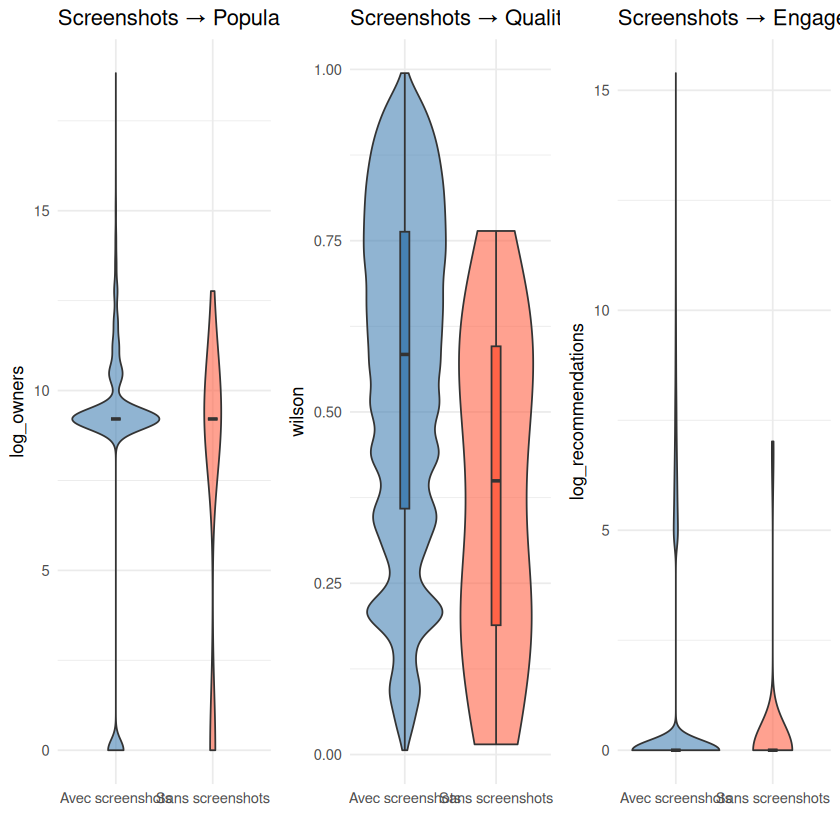

In [18]:
# Screenshots vs composantes du succès
p_sc_owners <- plot_binary_vs_success(df_analysis, "has_screenshots", "log_owners",
                               "Avec screenshots", "Sans screenshots",
                               "Screenshots → Popularité")
p_sc_wilson <- plot_binary_vs_success(df_analysis, "has_screenshots", "wilson",
                               "Avec screenshots", "Sans screenshots",
                               "Screenshots → Qualité perçue")
p_sc_recomm <- plot_binary_vs_success(df_analysis, "has_screenshots", "log_recommendations",
                               "Avec screenshots", "Sans screenshots",
                               "Screenshots → Engagement")

gridExtra::grid.arrange(p_sc_owners, p_sc_wilson, p_sc_recomm, ncol = 3)

# Tests
print(wilcox.test(log_owners ~ has_screenshots, data = df_analysis))
print(wilcox.test(wilson ~ has_screenshots, data = df_analysis))
print(wilcox.test(log_recommendations ~ has_screenshots, data = df_analysis))

# Médianes
df_analysis %>%
  group_by(has_screenshots) %>%
  summarise(
    log_owners_med = median(log_owners, na.rm = TRUE),
    wilson_med     = median(wilson, na.rm = TRUE),
    recomm_med     = median(log_recommendations, na.rm = TRUE),
    n = n()
  )

La présence de screenshots est associée à une meilleure qualité perçue (wilson 0.58 vs 0.39, p=7.8e-05) mais sans effet sur la popularité. Cependant avec seulement 60 jeux sans screenshots sur 113 000, le résultat n'est pas réellement interprétable. Les jeux sans screenshots sont quasi inexistants sur Steam, l'absence de screenshots est plus un signal de jeu abandonné ou non maintenu plûtot qu'une mauvaise performance.

## Langues Audio & Texte supportées

In [20]:
# 1. Distribution pour choisir les tranches
summary(df_analysis$nb_languages)
quantile(df_analysis$nb_languages, probs = c(0.25, 0.5, 0.75, 0.90, 0.95), na.rm = TRUE)

summary(df_analysis$nb_audio_languages)
quantile(df_analysis$nb_audio_languages, probs = c(0.25, 0.5, 0.75, 0.90, 0.95), na.rm = TRUE)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   1.000   5.596   5.000 103.000 

25% 50% 75% 90% 95% 
  1   1   5  11  17

Warning message:
“Unknown or uninitialised column: `nb_audio_languages`.”


Length  Class   Mode 
     0   NULL   NULL 

Warning message:
“Unknown or uninitialised column: `nb_audio_languages`.”


25% 50% 75% 90% 95% 
 NA  NA  NA  NA  NA

In [21]:
# Recréer nb_audio_languages dans df_analysis
df_analysis <- df_analysis %>%
  mutate(
    nb_audio_languages = str_count(`Full audio languages`, ",") + 1,
    nb_audio_languages = ifelse(`Full audio languages` == "[]" | 
                                 is.na(`Full audio languages`), 0, 
                                 nb_audio_languages),
    has_multi_audio = nb_audio_languages > 1
  )

# Vérification distributions
cat("=== LANGUES TEXTE ===\n")
summary(df_analysis$nb_languages)
quantile(df_analysis$nb_languages, probs = c(0.25, 0.5, 0.75, 0.90, 0.95), na.rm = TRUE)

cat("\n=== LANGUES AUDIO ===\n")
summary(df_analysis$nb_audio_languages)
quantile(df_analysis$nb_audio_languages, probs = c(0.25, 0.5, 0.75, 0.90, 0.95), na.rm = TRUE)

=== LANGUES TEXTE ===


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   1.000   5.596   5.000 103.000 

25% 50% 75% 90% 95% 
  1   1   5  11  17


=== LANGUES AUDIO ===


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   1.986   1.000 103.000 

25% 50% 75% 90% 95% 
  0   0   1   2   3

Warning message:
“Removed 33644 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 33644 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 33644 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 33644 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


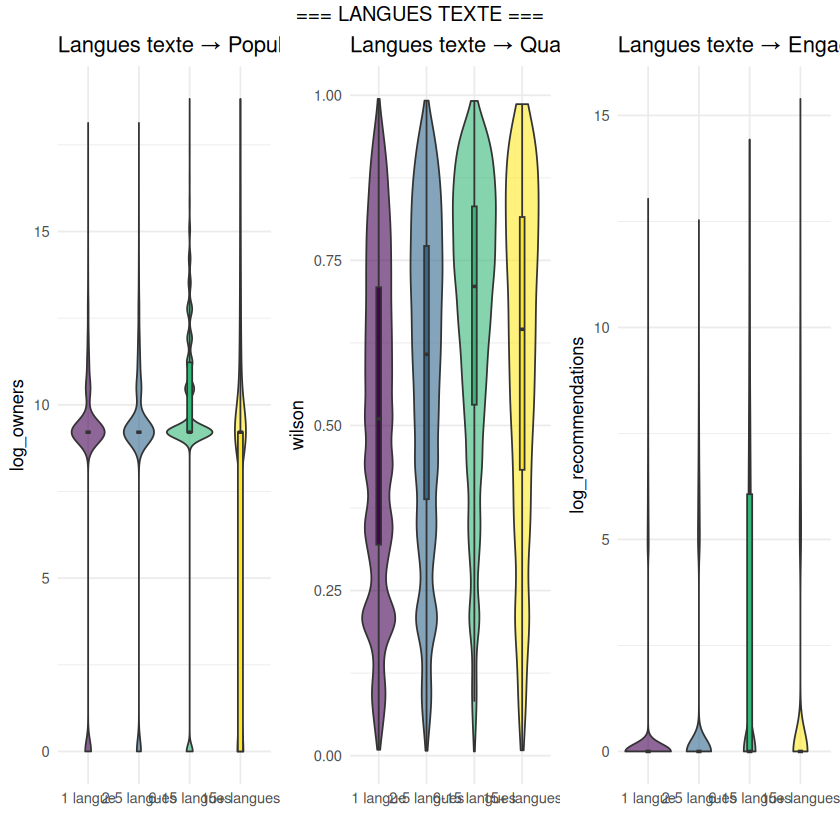

=== LANGUES TEXTE ===

	Kruskal-Wallis rank sum test

data:  log_owners by lang_group
Kruskal-Wallis chi-squared = 3852.6, df = 3, p-value < 2.2e-16


	Kruskal-Wallis rank sum test

data:  wilson by lang_group
Kruskal-Wallis chi-squared = 4667.6, df = 3, p-value < 2.2e-16


	Kruskal-Wallis rank sum test

data:  log_recommendations by lang_group
Kruskal-Wallis chi-squared = 11229, df = 3, p-value < 2.2e-16


=== LANGUES AUDIO ===

	Kruskal-Wallis rank sum test

data:  log_owners by audio_group
Kruskal-Wallis chi-squared = 1752.1, df = 3, p-value < 2.2e-16


	Kruskal-Wallis rank sum test

data:  wilson by audio_group
Kruskal-Wallis chi-squared = 2187, df = 3, p-value < 2.2e-16


	Kruskal-Wallis rank sum test

data:  log_recommendations by audio_group
Kruskal-Wallis chi-squared = 6690.6, df = 3, p-value < 2.2e-16


=== MEDIANES LANGUES TEXTE ===
# A tibble: 4 × 5
  lang_group   log_owners_med wilson_med recomm_med     n
  <fct>                 <dbl>      <dbl>      <dbl> <int>
1 1 langue 

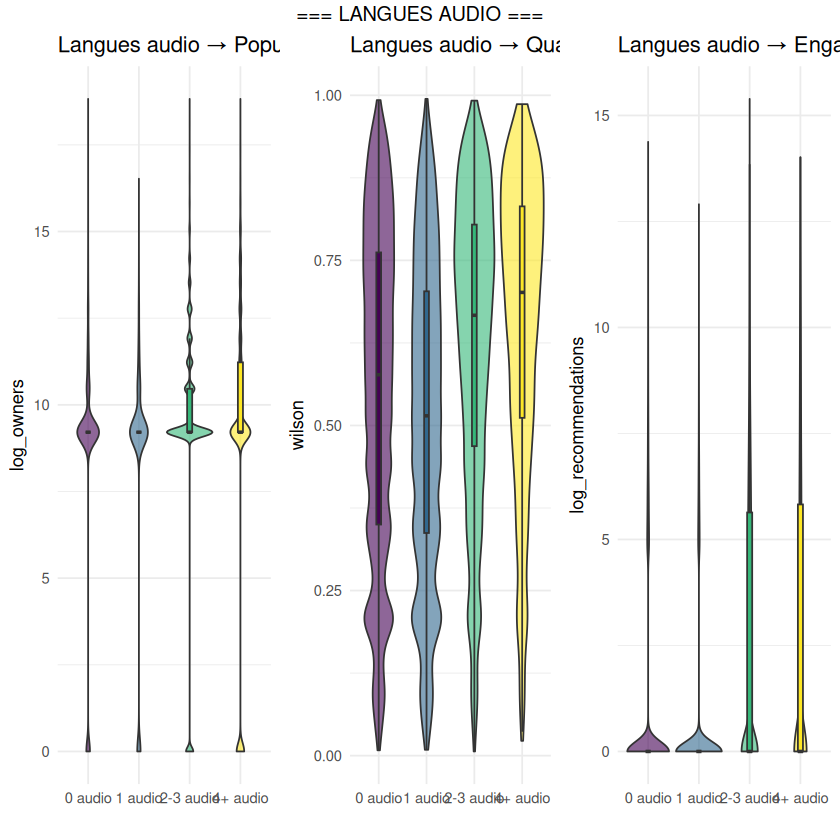

In [24]:
# Créer les groupes
df_analysis <- df_analysis %>%
  mutate(
    lang_group = case_when(
      nb_languages == 1  ~ "1 langue",
      nb_languages <= 5  ~ "2-5 langues",
      nb_languages <= 15 ~ "6-15 langues",
      TRUE               ~ "15+ langues"
    ) %>% factor(levels = c("1 langue", "2-5 langues", "6-15 langues", "15+ langues")),
    
    audio_group = case_when(
      nb_audio_languages == 0 ~ "0 audio",
      nb_audio_languages == 1 ~ "1 audio",
      nb_audio_languages <= 3 ~ "2-3 audio",
      TRUE                    ~ "4+ audio"
    ) %>% factor(levels = c("0 audio", "1 audio", "2-3 audio", "4+ audio"))
  )

# === LANGUES TEXTE ===
p_lt_owners <- ggplot(df_analysis, aes(x = lang_group, y = log_owners, fill = lang_group)) +
  geom_violin(alpha = 0.6) + geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Langues texte → Popularité", x = "", y = "log_owners") +
  theme_minimal() + theme(legend.position = "none")

p_lt_wilson <- ggplot(df_analysis, aes(x = lang_group, y = wilson, fill = lang_group)) +
  geom_violin(alpha = 0.6) + geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Langues texte → Qualité perçue", x = "", y = "wilson") +
  theme_minimal() + theme(legend.position = "none")

p_lt_recomm <- ggplot(df_analysis, aes(x = lang_group, y = log_recommendations, fill = lang_group)) +
  geom_violin(alpha = 0.6) + geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Langues texte → Engagement", x = "", y = "log_recommendations") +
  theme_minimal() + theme(legend.position = "none")

gridExtra::grid.arrange(p_lt_owners, p_lt_wilson, p_lt_recomm, ncol = 3,
                        top = "=== LANGUES TEXTE ===")

# === LANGUES AUDIO ===
p_la_owners <- ggplot(df_analysis, aes(x = audio_group, y = log_owners, fill = audio_group)) +
  geom_violin(alpha = 0.6) + geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Langues audio → Popularité", x = "", y = "log_owners") +
  theme_minimal() + theme(legend.position = "none")

p_la_wilson <- ggplot(df_analysis, aes(x = audio_group, y = wilson, fill = audio_group)) +
  geom_violin(alpha = 0.6) + geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Langues audio → Qualité perçue", x = "", y = "wilson") +
  theme_minimal() + theme(legend.position = "none")

p_la_recomm <- ggplot(df_analysis, aes(x = audio_group, y = log_recommendations, fill = audio_group)) +
  geom_violin(alpha = 0.6) + geom_boxplot(width = 0.1, outlier.shape = NA) +
  scale_fill_viridis_d() +
  labs(title = "Langues audio → Engagement", x = "", y = "log_recommendations") +
  theme_minimal() + theme(legend.position = "none")

gridExtra::grid.arrange(p_la_owners, p_la_wilson, p_la_recomm, ncol = 3,
                        top = "=== LANGUES AUDIO ===")

# === TESTS STATISTIQUES ===
cat("=== LANGUES TEXTE ===\n")
print(kruskal.test(log_owners ~ lang_group, data = df_analysis))
print(kruskal.test(wilson ~ lang_group, data = df_analysis))
print(kruskal.test(log_recommendations ~ lang_group, data = df_analysis))

cat("\n=== LANGUES AUDIO ===\n")
print(kruskal.test(log_owners ~ audio_group, data = df_analysis))
print(kruskal.test(wilson ~ audio_group, data = df_analysis))
print(kruskal.test(log_recommendations ~ audio_group, data = df_analysis))

# === MEDIANES ===
cat("\n=== MEDIANES LANGUES TEXTE ===\n")
df_analysis %>%
  group_by(lang_group) %>%
  summarise(
    log_owners_med = median(log_owners, na.rm = TRUE),
    wilson_med     = median(wilson, na.rm = TRUE),
    recomm_med     = median(log_recommendations, na.rm = TRUE),
    n = n()
  ) %>% print()

cat("\n=== MEDIANES LANGUES AUDIO ===\n")
df_analysis %>%
  group_by(audio_group) %>%
  summarise(
    log_owners_med = median(log_owners, na.rm = TRUE),
    wilson_med     = median(wilson, na.rm = TRUE),
    recomm_med     = median(log_recommendations, na.rm = TRUE),
    n = n()
  ) %>% print()

Langues texte : la baisse à 15+ langues (0.711 → 0.646) se relève. Les jeux avec énormément de langues ne sont pas forcément les mieux perçus, probablement des jeux qui investissent dans la localisation mais pas dans la qualité du jeu lui-même.
Langues audio : le groupe "0 audio" a un wilson plus élevé (0.577) que "1 audio" (0.515). Un jeu sans aucun audio du tout peut quand même être bien perçu, typiquement les jeux de puzzle, stratégie, casual.

Même conclusion qu'OS et DLC sur la causalité

Le nombre de langues supportées est significativement associé à la qualité perçue (p < 2.2e-16) mais sans effet sur la popularité, log_owners reste identique (9.21) quel que soit le nombre de langues. L'effet de seuil observé pour les langues texte (baisse au-delà de 15 langues) peut montrer que la localisation abusive ne compense pas une qualité insuffisante. Comme pour le support multiplateforme, le nombre de langues reflète plus les ressources du studio que l'attractivité du jeu.